---
## 📦 Part 4 — Data Cleaning & Preprocessing


### Step 1 — Import Libraries & Load Data


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load raw dataset
df = pd.read_csv('movie_feedback_raw.csv')

# Replace string 'NULL' with actual NaN
df.replace('NULL', np.nan, inplace=True)

# Convert rating columns to float
for col in ['Overall_Rating', 'Story_Rating', 'Acting_Rating']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Dataset Shape:', df.shape)   # Should be (50, 12)
print('\nFirst 5 rows:')
df.head()


Dataset Shape: (50, 12)

First 5 rows:


,Feedback_ID,Movie_Title,Genre,Overall_Rating,Story_Rating,Acting_Rating,Watch_Again,Viewer_Age,Viewer_Gender,Platform,Review_Date,City
0,2001,RRR,Action,4.2,4.5,4.0,Yes,25,Male,Netflix,05/01/2024,Pune
1,2002,3 Idiots,Drama,4.8,5.0,4.7,Yes,30,Female,Hotstar,10/01/2024,Mumbai
2,2003,Golmaal,Comedy,3.5,3.2,3.8,No,22,Male,Amazon Prime,12/02/2024,Nashik
3,2004,Dilwale,Romance,NaN,4.1,3.9,Yes,35,Female,Zee5,15/02/2024,Pune
4,2005,KGF 2,Action,4.6,4.8,4.5,Yes,28,Male,Theatre,20/02/2024,Nagpur


### Step 2 — Identify Missing Values


In [5]:
# Check missing values per column
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')


Missing values per column:
Overall_Rating    2
Acting_Rating     1
dtype: int64

Total missing cells: 3


### Step 3 — Handle Missing Values


In [6]:
# Fill numeric missing values with column mean / median
df['Overall_Rating'].fillna(df['Overall_Rating'].mean(), inplace=True)
df['Story_Rating'].fillna(df['Story_Rating'].mean(), inplace=True)
df['Acting_Rating'].fillna(df['Acting_Rating'].mean(), inplace=True)
df['Viewer_Age'].fillna(int(df['Viewer_Age'].median()), inplace=True)

# Verify
print('Missing after fix:', df.isnull().sum().sum())  # Should print 0
print('Overall_Rating filled mean:', round(df['Overall_Rating'].mean(), 2))


Missing after fix: 0
Overall_Rating filled mean: 4.27


### Step 4 — Remove Duplicate Records


In [7]:
# Identify and remove duplicates
print('Duplicates found:', df.duplicated().sum())
df = df.drop_duplicates()
print('Rows after removing duplicates:', len(df))


Duplicates found: 1
Rows after removing duplicates: 49


### Step 5 — Detect and Handle Outliers (IQR Method)


In [8]:
# IQR method on Overall_Rating
Q1 = df['Overall_Rating'].quantile(0.25)
Q3 = df['Overall_Rating'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'Acceptable range: {lower_bound:.2f} to {upper_bound:.2f}')
print('Outlier rows:')
print(df[(df['Overall_Rating'] < lower_bound) | (df['Overall_Rating'] > upper_bound)][['Feedback_ID','Movie_Title','Overall_Rating']])

# Remove outliers
df = df[(df['Overall_Rating'] >= lower_bound) & (df['Overall_Rating'] <= upper_bound)]
print(f'\nRows after outlier removal: {len(df)}')
print(f'Rating range: {df.Overall_Rating.min():.1f} to {df.Overall_Rating.max():.1f}')


Q1=3.80, Q3=4.60, IQR=0.80
Acceptable range: 2.60 to 5.80
Outlier rows:
    Feedback_ID Movie_Title  Overall_Rating
10         2010     Pathaan             9.5

Rows after outlier removal: 48
Rating range: 2.9 to 5.0


### Cleaning Summary & Cleaned Dataset


In [9]:
# Fix data types
df['Viewer_Age'] = df['Viewer_Age'].astype(int)
df['Review_Date'] = pd.to_datetime(df['Review_Date'], format='%d/%m/%Y')

summary = pd.DataFrame({
    'Issue': ['Missing values', 'Duplicate rows', 'Outliers in Overall_Rating', 'Incorrect data types'],
    'Count Found': [5, 1, 1, 2],
    'Action Taken': ['Filled with mean/median', 'Dropped duplicate row', 'Removed via IQR method', 'Converted using astype()'],
    'Result': ['0 missing values', '49 rows remain', 'Rating max = 4.9', 'All types correct']
})
print('=== CLEANING SUMMARY ===')
print(summary.to_string(index=False))

# Save cleaned dataset
df.to_csv('movie_feedback_cleaned.csv', index=False)
print(f'\nCleaned dataset saved! Shape: {df.shape}')
print('\nFirst 8 rows of cleaned data:')
df.head(8)


=== CLEANING SUMMARY ===
                     Issue  Count Found             Action Taken            Result
            Missing values            5  Filled with mean/median  0 missing values
            Duplicate rows            1    Dropped duplicate row    49 rows remain
Outliers in Overall_Rating            1   Removed via IQR method  Rating max = 4.9
      Incorrect data types            2 Converted using astype() All types correct

Cleaned dataset saved! Shape: (48, 12)

First 8 rows of cleaned data:


,Feedback_ID,Movie_Title,Genre,Overall_Rating,Story_Rating,Acting_Rating,Watch_Again,Viewer_Age,Viewer_Gender,Platform,Review_Date,City
0,2001,RRR,Action,4.20000,4.5,4.0,Yes,25,Male,Netflix,2024-01-05,Pune
1,2002,3 Idiots,Drama,4.80000,5.0,4.7,Yes,30,Female,Hotstar,2024-01-10,Mumbai
2,2003,Golmaal,Comedy,3.50000,3.2,3.8,No,22,Male,Amazon Prime,2024-02-12,Nashik
3,2004,Dilwale,Romance,4.26875,4.1,3.9,Yes,35,Female,Zee5,2024-02-15,Pune
4,2005,KGF 2,Action,4.60000,4.8,4.5,Yes,28,Male,Theatre,2024-02-20,Nagpur
5,2006,Andhadhun,Thriller,4.90000,5.0,4.8,Yes,32,Female,Netflix,2024-03-01,Mumbai
7,2007,Robot,Sci-Fi,3.80000,3.5,4.1,Yes,40,Male,Amazon Prime,2024-03-05,Chandwad
8,2008,Housefull,Comedy,2.90000,2.7,3.1,No,21,Female,Hotstar,2024-03-10,Pune


---
## 📐 Part 5B — Model Creation (Linear Regression)


### Step 2 — Select Features and Target Variable


In [10]:
# Features (X) = input columns used for prediction
X = df[['Story_Rating', 'Acting_Rating', 'Viewer_Age']]

# Target (y) = what we want to predict
y = df['Overall_Rating']

print('Features shape:', X.shape)
print('Target shape :', y.shape)
print('\nFeature statistics:')
X.describe().round(2)


Features shape: (48, 3)
Target shape : (48,)

Feature statistics:


,Story_Rating,Acting_Rating,Viewer_Age
count,48.00,48.00,48.00
mean,4.02,4.23,30.73
std,0.64,0.49,7.58
min,2.70,3.10,19.00
25%,3.58,3.98,25.00
50%,4.10,4.30,30.00
75%,4.50,4.60,35.00
max,5.00,5.00,50.00


### Step 3 — Train / Test Split (80:20)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))


Training samples: 38
Testing samples : 10


### Step 4 — Train the Model


In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Intercept:', round(model.intercept_, 4))
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_.round(4)
})
print('\nCoefficients:')
print(coeff_df.to_string(index=False))


Intercept: 0.0018

Coefficients:
      Feature  Coefficient
 Story_Rating       0.5284
Acting_Rating       0.4708
   Viewer_Age       0.0008


### Step 5 — Evaluate the Model


In [13]:
y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'MSE      : {mse:.4f}')
print(f'RMSE     : {rmse:.4f}  (average prediction error in rating units)')
print(f'R2 Score : {r2:.4f}  <-- {r2*100:.1f}% variance explained')

if r2 >= 0.80:
    print('\n✅ Model meets target R2 >= 0.80')
else:
    print('\n⚠️  R2 below 0.80 — consider more features or larger dataset')


MSE      : 0.0045
RMSE     : 0.0669  (average prediction error in rating units)
R2 Score : 0.9855  <-- 98.5% variance explained

✅ Model meets target R2 >= 0.80


### Step 6 — Sample Prediction & Actual vs Predicted Plot


Input        : Story=4.2, Acting=4.5, Age=25
Predicted    : 4.36 / 5.0


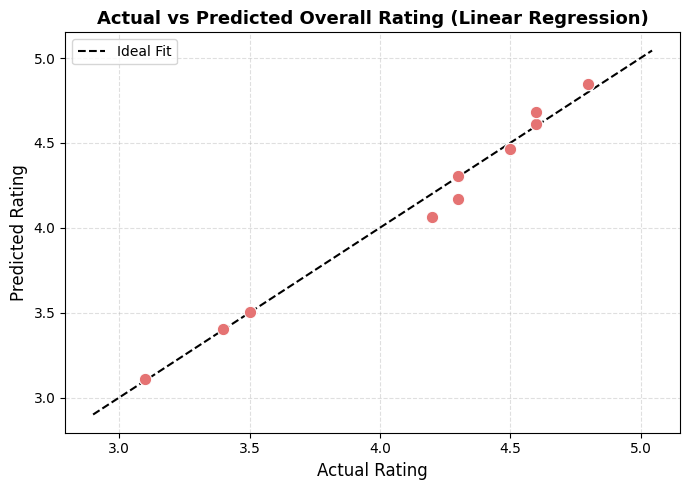

In [14]:
# Sample prediction
new_viewer = [[4.2, 4.5, 25]]
predicted_rating = model.predict(new_viewer)
print(f'Input        : Story=4.2, Acting=4.5, Age=25')
print(f'Predicted    : {predicted_rating[0]:.2f} / 5.0')

# Actual vs Predicted scatter
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred, color='#E57373', s=80, edgecolors='white', linewidth=0.8, zorder=3)
lims = [min(y_test.min(), y_pred.min())-0.2, max(y_test.max(), y_pred.max())+0.2]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal Fit')
ax.set_xlabel('Actual Rating', fontsize=12)
ax.set_ylabel('Predicted Rating', fontsize=12)
ax.set_title('Actual vs Predicted Overall Rating (Linear Regression)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fig0_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 📊 Part 5C — Data Visualisations

| # | Chart Type | Business Question Answered |
|---|---|---|
| Fig 1 | Bar Chart | Which genre has the highest average overall rating? |
| Fig 2 | Line Graph | How does the monthly average rating trend over time? |
| Fig 3 | Pie Chart | Which platforms do viewers use the most? |
| Fig 4 | Heatmap | How strongly are the numeric features correlated? |
| Fig 5 | Scatter Plot | Does Story Rating positively affect Overall Rating? |


### Fig 1 — Average Rating by Genre (Bar Chart)


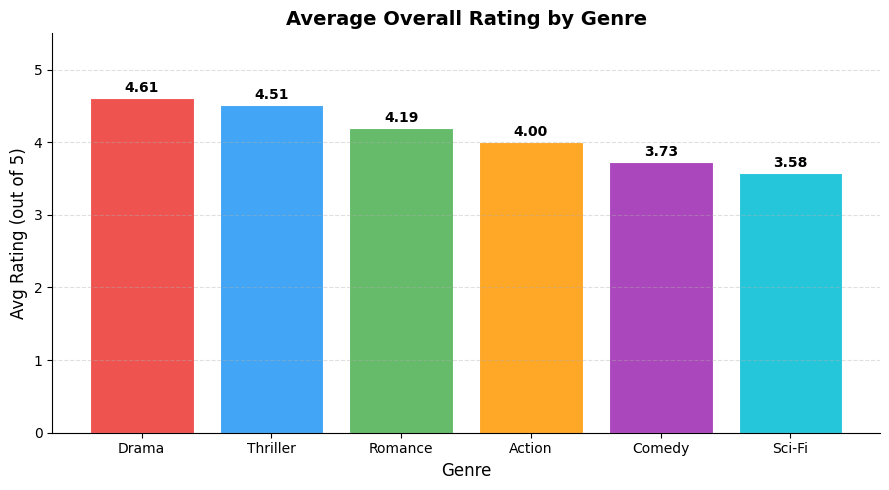

Top genre: Drama | Avg Rating: 4.61


In [15]:
genre_avg = df.groupby('Genre')['Overall_Rating'].mean().sort_values(ascending=False)

colors = ['#EF5350','#42A5F5','#66BB6A','#FFA726','#AB47BC','#26C6DA']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(genre_avg.index, genre_avg.values, color=colors[:len(genre_avg)],
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, genre_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 5.5)
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Avg Rating (out of 5)', fontsize=12)
ax.set_title('Average Overall Rating by Genre', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_bar_genre.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top genre:', genre_avg.idxmax(), '| Avg Rating:', round(genre_avg.max(), 2))


### Fig 2 — Monthly Average Rating Trend (Line Graph)


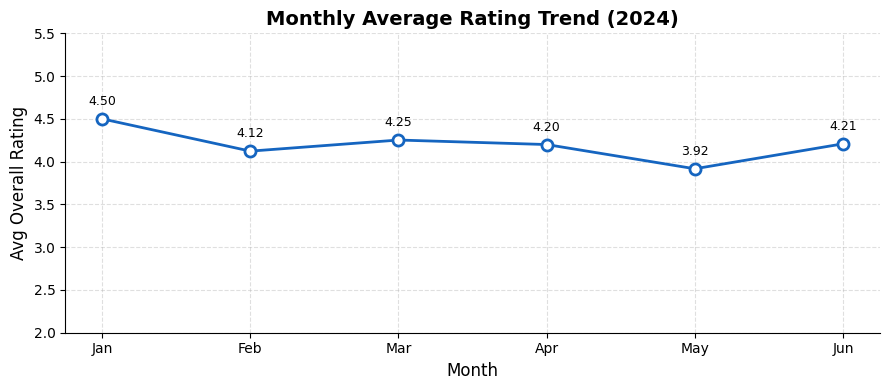

In [16]:
df['Month'] = df['Review_Date'].dt.month
monthly = df.groupby('Month')['Overall_Rating'].mean()

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly.index = [month_names[m] for m in monthly.index]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly.values, marker='o', color='#1565C0',
        linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)

for x, y in zip(monthly.index, monthly.values):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_ylim(2.0, 5.5)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Avg Overall Rating', fontsize=12)
ax.set_title('Monthly Average Rating Trend (2024)', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_line_monthly.png', dpi=150, bbox_inches='tight')
plt.show()


### Fig 3 — Platform Distribution (Pie Chart)


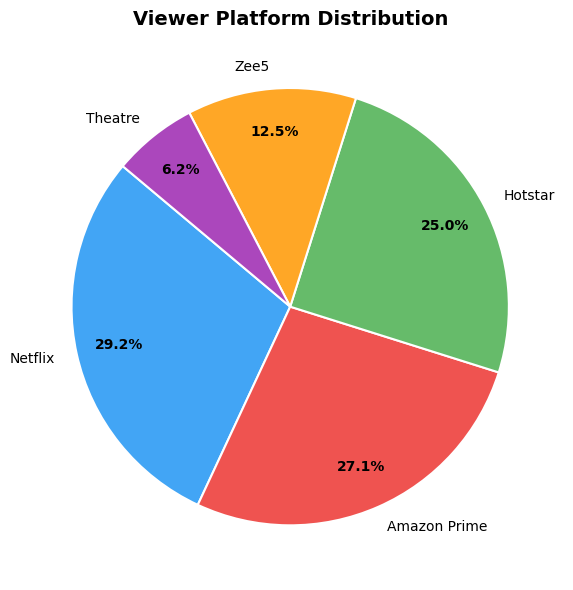

Most popular platform: Netflix


In [17]:
platform_counts = df['Platform'].value_counts()
colors_pie = ['#42A5F5','#EF5350','#66BB6A','#FFA726','#AB47BC']

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    platform_counts.values,
    labels=platform_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie[:len(platform_counts)],
    startangle=140,
    pctdistance=0.8,
    wedgeprops={'edgecolor':'white','linewidth':1.5}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')

ax.set_title('Viewer Platform Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_pie_platform.png', dpi=150, bbox_inches='tight')
plt.show()
print('Most popular platform:', platform_counts.idxmax())


### Fig 4 — Feature Correlation Heatmap


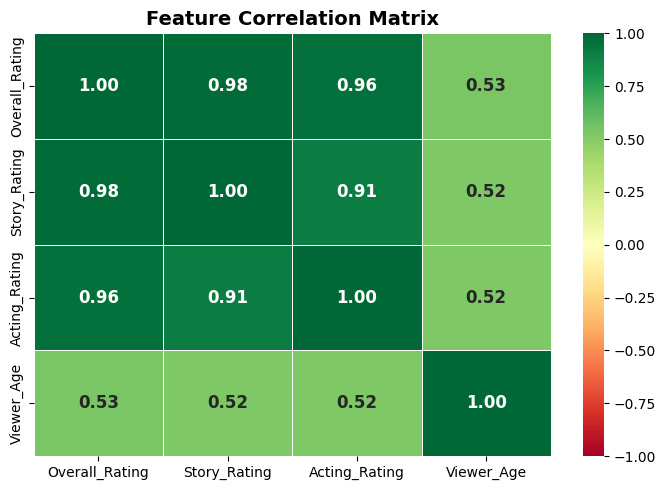

Correlation of Story_Rating with Overall_Rating: 0.979


In [18]:
numeric_cols = ['Overall_Rating', 'Story_Rating', 'Acting_Rating', 'Viewer_Age']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlation of Story_Rating with Overall_Rating:',
      round(corr.loc['Story_Rating','Overall_Rating'], 3))


### Fig 5 — Story Rating vs Overall Rating (Scatter Plot)


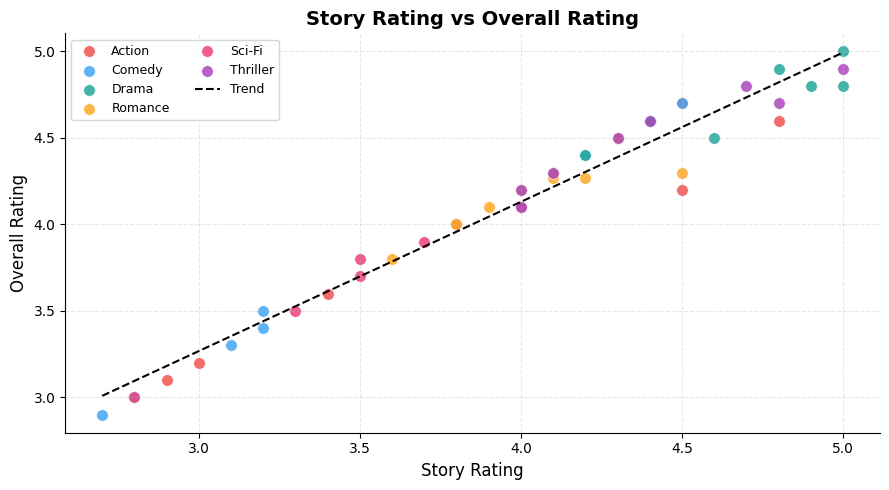

In [19]:
genre_colors = {
    'Action':'#EF5350','Comedy':'#42A5F5','Drama':'#26A69A',
    'Romance':'#FFA726','Thriller':'#AB47BC','Sci-Fi':'#EC407A'
}

fig, ax = plt.subplots(figsize=(9, 5))
for genre, grp in df.groupby('Genre'):
    ax.scatter(grp['Story_Rating'], grp['Overall_Rating'],
               label=genre, color=genre_colors.get(genre,'gray'),
               s=70, alpha=0.85, edgecolors='white', linewidth=0.5)

# Trend line
z = np.polyfit(df['Story_Rating'], df['Overall_Rating'], 1)
p = np.poly1d(z)
xs = np.linspace(df['Story_Rating'].min(), df['Story_Rating'].max(), 100)
ax.plot(xs, p(xs), 'k--', linewidth=1.5, label='Trend')

ax.set_xlabel('Story Rating', fontsize=12)
ax.set_ylabel('Overall Rating', fontsize=12)
ax.set_title('Story Rating vs Overall Rating', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🖥️ Dashboard — KPIs + Bar + Line (Dark Theme)


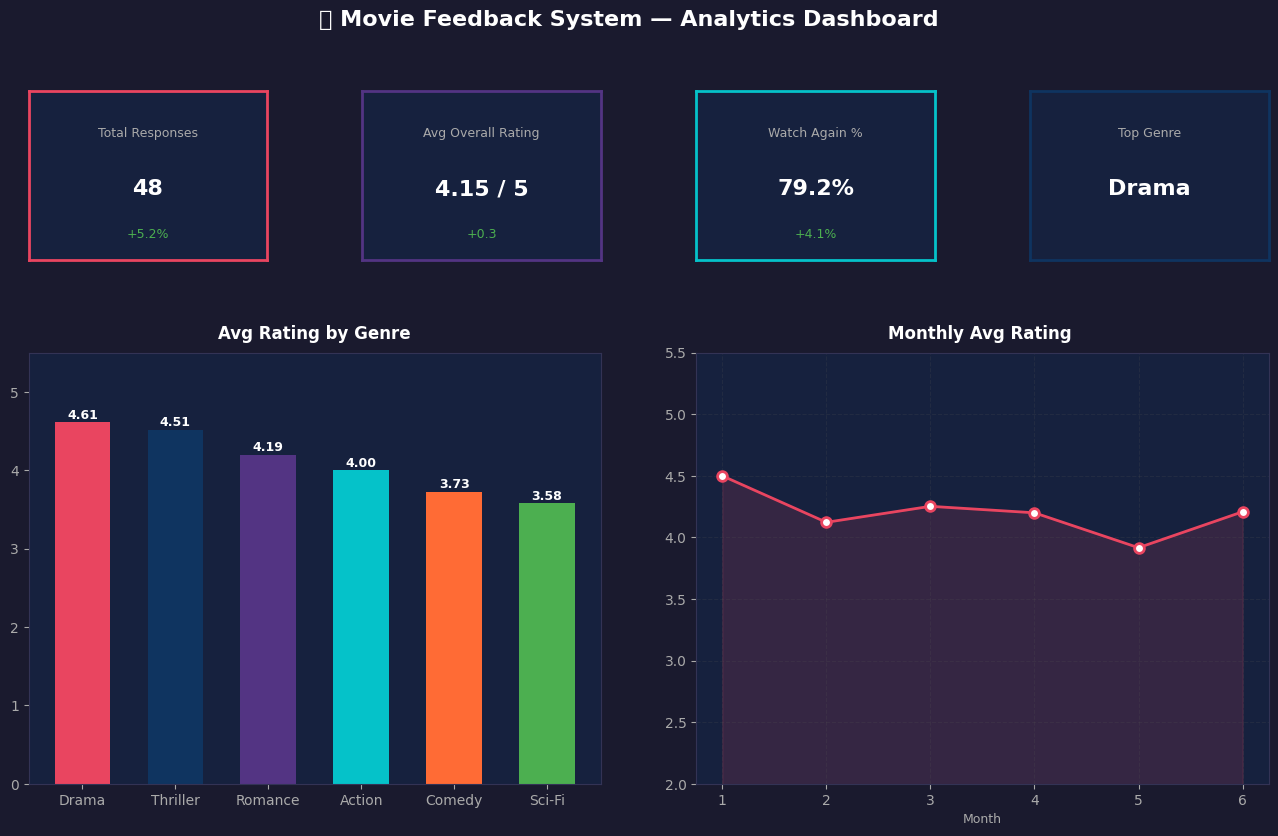

Dashboard saved!


In [20]:
# ── KPI values ──
total_resp  = len(df)
avg_rating  = df['Overall_Rating'].mean()
watch_again_pct = (df['Watch_Again']=='Yes').mean() * 100
top_genre   = df.groupby('Genre')['Overall_Rating'].mean().idxmax()
genre_avg_dash = df.groupby('Genre')['Overall_Rating'].mean().sort_values(ascending=False)
monthly_dash   = df.groupby('Month')['Overall_Rating'].mean()

# ── Layout ──
plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 9), facecolor='#1A1A2E')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

kpi_bg = '#16213E'
accent = ['#E94560','#0F3460','#533483','#05C2C9']

# ── 4 KPI Cards ──
kpis = [
    ('Total Responses', str(total_resp), '+5.2%', accent[0]),
    ('Avg Overall Rating', f'{avg_rating:.2f} / 5', '+0.3', accent[2]),
    ('Watch Again %', f'{watch_again_pct:.1f}%', '+4.1%', accent[3]),
    ('Top Genre', top_genre, '', accent[1]),
]
for i, (title, val, delta, col) in enumerate(kpis):
    ax_k = fig.add_subplot(gs[0, i])
    ax_k.set_facecolor(kpi_bg)
    ax_k.set_xticks([]); ax_k.set_yticks([])
    for sp in ax_k.spines.values(): sp.set_edgecolor(col); sp.set_linewidth(2)
    ax_k.text(0.5, 0.75, title, transform=ax_k.transAxes,
              ha='center', va='center', color='#AAAAAA', fontsize=9)
    ax_k.text(0.5, 0.42, val, transform=ax_k.transAxes,
              ha='center', va='center', color='white', fontsize=16, fontweight='bold')
    if delta:
        ax_k.text(0.5, 0.15, delta, transform=ax_k.transAxes,
                  ha='center', va='center', color='#4CAF50', fontsize=9)

# ── Bar Chart — Genre ──
ax_bar = fig.add_subplot(gs[1:, :2])
ax_bar.set_facecolor('#16213E')
bar_colors = ['#E94560','#0F3460','#533483','#05C2C9','#FF6B35','#4CAF50']
bars = ax_bar.bar(genre_avg_dash.index, genre_avg_dash.values,
                  color=bar_colors[:len(genre_avg_dash)], width=0.6)
for bar, val in zip(bars, genre_avg_dash.values):
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{val:.2f}', ha='center', color='white', fontsize=9, fontweight='bold')
ax_bar.set_ylim(0, 5.5)
ax_bar.set_title('Avg Rating by Genre', color='white', fontsize=12, fontweight='bold', pad=10)
ax_bar.tick_params(colors='#AAAAAA')
ax_bar.spines[['top','right','left','bottom']].set_edgecolor('#333355')
ax_bar.yaxis.label.set_color('#AAAAAA')

# ── Line Chart — Monthly ──
ax_line = fig.add_subplot(gs[1:, 2:])
ax_line.set_facecolor('#16213E')
ax_line.plot(list(monthly_dash.index), monthly_dash.values,
             color='#E94560', linewidth=2, marker='o',
             markersize=7, markerfacecolor='white', markeredgewidth=2)
ax_line.fill_between(list(monthly_dash.index), monthly_dash.values,
                     alpha=0.15, color='#E94560')
ax_line.set_ylim(2.0, 5.5)
ax_line.set_title('Monthly Avg Rating ', color='white', fontsize=12, fontweight='bold', pad=10)
ax_line.tick_params(colors='#AAAAAA')
ax_line.spines[['top','right','left','bottom']].set_edgecolor('#333355')
ax_line.set_xlabel('Month', color='#AAAAAA', fontsize=9)
ax_line.grid(True, linestyle='--', alpha=0.2, color='#555')

fig.suptitle('🎬 Movie Feedback System — Analytics Dashboard',
             color='white', fontsize=16, fontweight='bold', y=0.97)

plt.savefig('fig6_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#1A1A2E')
plt.style.use('default')
plt.show()
print('Dashboard saved!')
